In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [84]:
from sklearn.model_selection import train_test_split

In [85]:
df = pd.read_csv('./xg_model.csv')

In [86]:
df

,x,y,is_goal,period,Assisted,Zone,IndividualPlay,RegularPlay,LeftFoot,RightFoot,...,Volley,FastBreak,ThrowinSetPiece,Penalty,OneOnOne,KeyPass,DirectFreekick,OwnGoal,OtherBodyPart,DirectCorner
0,80.8,51.6,False,SecondHalf,True,Center,True,True,True,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,79.3,24.2,False,SecondHalf,True,Center,True,True,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,80.0,59.5,False,SecondHalf,True,Center,NaN,NaN,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,89.8,55.6,False,SecondHalf,True,Center,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,84.9,56.2,False,SecondHalf,True,Center,NaN,True,True,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8113,86.4,34.0,False,FirstHalf,NaN,Center,NaN,True,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8114,92.4,51.0,False,FirstHalf,True,Center,NaN,True,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8115,88.6,37.8,False,FirstHalf,True,Center,NaN,True,NaN,True,...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8116,89.6,48.1,False,FirstHalf,True,Center,NaN,True,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [87]:
df.drop(['DirectFreekick', 'DirectCorner'], axis = 1, inplace = True)

In [88]:
df = df[df['OwnGoal'] != True]

In [89]:
df.drop(['OwnGoal'], axis = 1, inplace = True)

/var/folders/jx/t1vcqq5n5r7629tr1v1zjkj80000gp/T/ipykernel_46438/3406361940.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(['OwnGoal'], axis = 1, inplace = True)


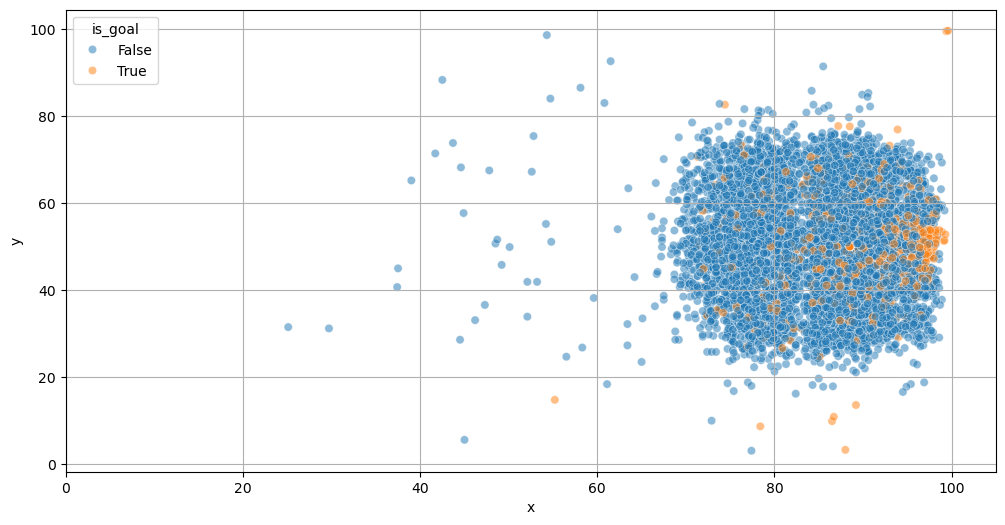

In [90]:
plt.figure(figsize = (12,6))
sns.scatterplot(x='x', y='y', data=df, hue='is_goal', alpha = 0.5)
plt.xlim([0, 105])  # Replace xmin and xmax with your desired limits
plt.grid()
# plt.show()

In [91]:
df.fillna(0, inplace=True)

/var/folders/jx/t1vcqq5n5r7629tr1v1zjkj80000gp/T/ipykernel_46438/4231983114.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.fillna(0, inplace=True)


In [94]:
df = df.astype({
    'x': float,
    'y': float,
    'is_goal': bool,
    'period': str,
    'Assisted': bool,
    'Zone': str,
    'IndividualPlay':bool,
    'RegularPlay':bool,
    'LeftFoot':bool,
    'RightFoot':bool,
    'FromCorner':bool,
    'FirstTouch':bool, 
    'Head':bool,
    'BigChance': bool,
    'SetPiece': bool,
    'Volley': bool,
    'FastBreak':bool,
    'ThrowinSetPiece':bool,
    'Penalty':bool, 
    'OneOnOne':bool,
    'KeyPass': bool,
    'OtherBodyPart': bool
})

In [95]:
df

,x,y,is_goal,period,Assisted,Zone,IndividualPlay,RegularPlay,LeftFoot,RightFoot,...,Head,BigChance,SetPiece,Volley,FastBreak,ThrowinSetPiece,Penalty,OneOnOne,KeyPass,OtherBodyPart
0,80.8,51.6,False,SecondHalf,True,Center,True,True,True,False,...,False,False,False,False,False,False,False,False,False,False
1,79.3,24.2,False,SecondHalf,True,Center,True,True,False,True,...,False,False,False,False,False,False,False,False,False,False
2,80.0,59.5,False,SecondHalf,True,Center,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,89.8,55.6,False,SecondHalf,True,Center,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
4,84.9,56.2,False,SecondHalf,True,Center,False,True,True,False,...,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8113,86.4,34.0,False,FirstHalf,False,Center,False,True,False,True,...,False,True,False,False,False,False,False,False,False,False
8114,92.4,51.0,False,FirstHalf,True,Center,False,True,False,False,...,True,True,False,False,False,False,False,False,False,False
8115,88.6,37.8,False,FirstHalf,True,Center,False,True,False,True,...,False,False,False,True,False,False,False,False,False,False
8116,89.6,48.1,False,FirstHalf,True,Center,False,True,False,False,...,True,True,False,False,False,False,False,False,False,False


In [96]:
df.is_goal.value_counts()

is_goal
False    7097
True      994
Name: count, dtype: int64

In [100]:
goal_y = 50
goal_x = 100

df['shot_dist'] = np.sqrt((df.x - goal_x) ** 2 + (df.y - goal_y) ** 2)
df['angle'] = np.degrees(np.arctan2(goal_y - df.y, goal_x - df.x))

In [101]:
df['angle'].describe()

count    8091.000000
mean        0.033898
std        40.228605
min       -89.537947
25%       -33.838556
50%         0.000000
75%        33.577373
max        86.167730
Name: angle, dtype: float64

<Axes: >

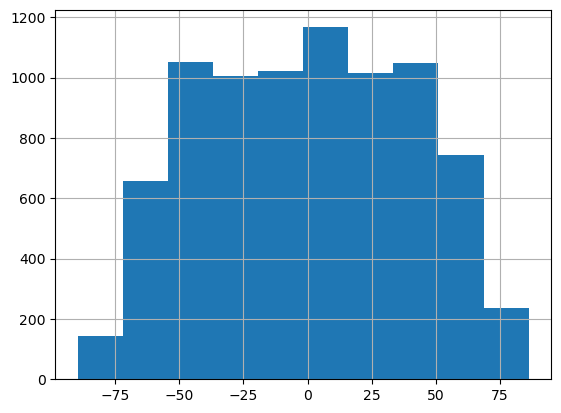

In [102]:
df.angle.hist()

In [103]:
df = pd.get_dummies(df, columns = ['period', 'Zone'])

In [104]:
df

,x,y,is_goal,Assisted,IndividualPlay,RegularPlay,LeftFoot,RightFoot,FromCorner,FirstTouch,...,KeyPass,OtherBodyPart,shot_dist,angle,period_FirstHalf,period_SecondHalf,Zone_Back,Zone_Center,Zone_Left,Zone_Right
0,80.8,51.6,False,True,True,True,True,False,False,False,...,False,False,19.266551,-4.763642,False,True,False,True,False,False
1,79.3,24.2,False,True,True,True,False,True,False,False,...,False,False,33.077636,51.259036,False,True,False,True,False,False
2,80.0,59.5,False,True,False,False,False,True,True,False,...,False,False,22.141590,-25.407718,False,True,False,True,False,False
3,89.8,55.6,False,True,False,False,False,False,True,True,...,False,False,11.636151,-28.767649,False,True,False,True,False,False
4,84.9,56.2,False,True,False,True,True,False,False,False,...,False,False,16.323296,-22.322858,False,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8113,86.4,34.0,False,False,False,True,False,True,False,True,...,False,False,20.999048,49.635463,True,False,False,True,False,False
8114,92.4,51.0,False,True,False,True,False,False,False,True,...,False,False,7.665507,-7.495858,True,False,False,True,False,False
8115,88.6,37.8,False,True,False,True,False,True,False,True,...,False,False,16.697305,46.941486,True,False,False,True,False,False
8116,89.6,48.1,False,True,False,True,False,False,False,True,...,False,False,10.572133,10.353320,True,False,False,True,False,False


In [105]:
df.OtherBodyPart.value_counts()

OtherBodyPart
False    8067
True       24
Name: count, dtype: int64

In [113]:
columns_to_drop = ['is_goal', 'Penalty']
X = df.drop(columns_to_drop, axis = 1)
y = df['is_goal']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((6472, 26), (1619, 26), (6472,), (1619,))

In [ ]:
# use logistic regression
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Goal', 'Goal'], yticklabels=['No Goal', 'Goal'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# find the probabilities of the test set
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred_proba

Accuracy: 0.8943792464484249
              precision    recall  f1-score   support

       False       0.90      0.99      0.94      1435
        True       0.62      0.18      0.28       184

    accuracy                           0.89      1619
   macro avg       0.76      0.58      0.61      1619
weighted avg       0.87      0.89      0.87      1619



/opt/anaconda3/envs/testenv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array([0.0711741 , 0.36783797, 0.03463166, ..., 0.03402337, 0.07395084,
       0.38143188])

Log Loss: 0.27049593375415926
ROC AUC: 0.8104150886229359
Brier Score: 0.07750965577752836


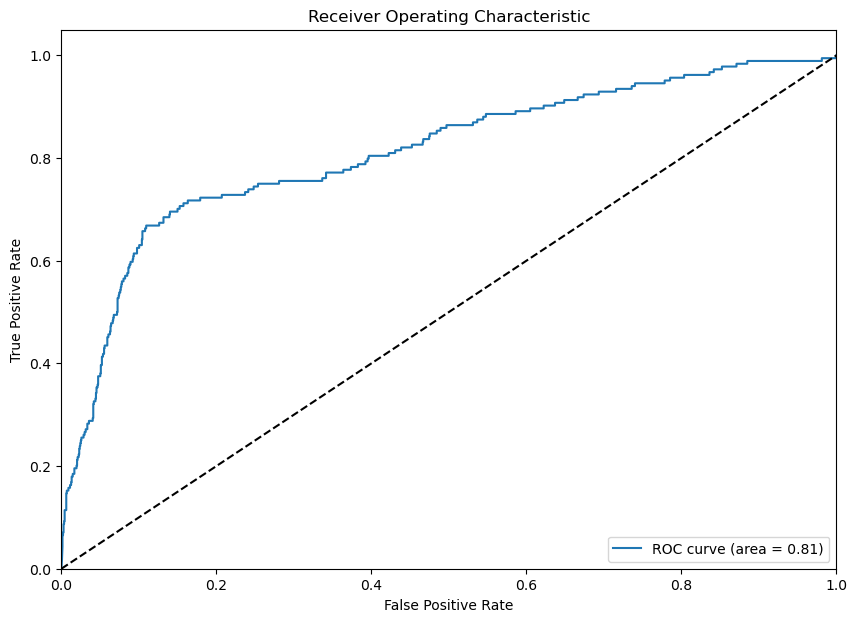

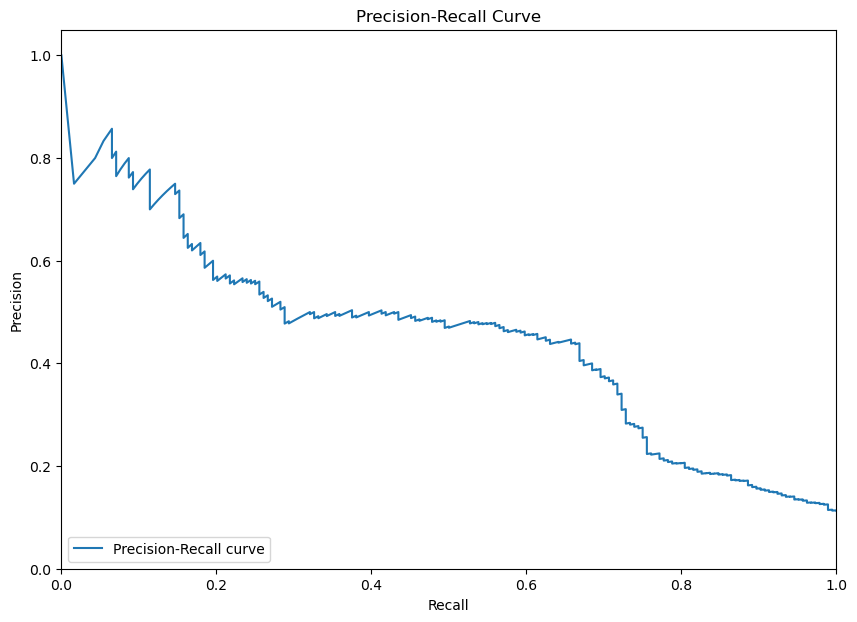

In [115]:
# find the log loss, ROC AUC and brier score
from sklearn.metrics import log_loss, roc_auc_score, brier_score_loss
print("Log Loss:", log_loss(y_test, y_pred_proba))
print("ROC AUC:", roc_auc_score(y_test, y_pred_proba))
print("Brier Score:", brier_score_loss(y_test, y_pred_proba))
# plot the ROC curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_pred_proba))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()
# plot the precision recall curve
from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
plt.figure(figsize=(10, 7))
plt.plot(recall, precision, label='Precision-Recall curve')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()

In [116]:
final_df = X_test.copy()
final_df['goal_predicted'] = y_pred
final_df['goal_probability'] = y_pred_proba


In [117]:
final_df

,x,y,Assisted,IndividualPlay,RegularPlay,LeftFoot,RightFoot,FromCorner,FirstTouch,Head,...,shot_dist,angle,period_FirstHalf,period_SecondHalf,Zone_Back,Zone_Center,Zone_Left,Zone_Right,goal_predicted,goal_probability
4208,87.0,56.4,True,False,True,False,True,False,True,False,...,14.489997,-26.211378,False,True,False,True,False,False,False,0.071174
4180,97.9,52.8,True,False,True,False,False,False,True,True,...,3.500000,-53.130102,False,True,False,True,False,False,False,0.367838
1933,97.0,41.9,True,False,False,False,False,True,True,True,...,8.637708,69.676863,True,False,False,True,False,False,False,0.034632
1063,73.1,37.4,True,True,True,True,False,False,False,False,...,29.704713,25.098462,True,False,False,True,False,False,False,0.036106
737,82.7,54.0,True,True,True,False,True,False,False,False,...,17.756407,-13.018802,False,True,False,True,False,False,False,0.100534
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5787,86.7,62.0,True,False,True,False,True,False,True,False,...,17.913403,-42.058535,True,False,False,True,False,False,False,0.049543
4520,88.7,40.1,True,False,True,False,True,False,True,False,...,15.023315,41.221802,False,True,False,True,False,False,False,0.062112
4464,76.4,32.4,True,True,True,False,True,False,False,False,...,29.440109,36.714203,True,False,False,True,False,False,False,0.034023
2204,85.5,65.4,False,True,True,False,True,False,False,False,...,21.152068,-46.724102,False,True,False,True,False,False,False,0.073951


In [118]:
final_df.sort_values(by = 'goal_probability', ascending = False, inplace = True)

In [119]:
final_df.head(20)

,x,y,Assisted,IndividualPlay,RegularPlay,LeftFoot,RightFoot,FromCorner,FirstTouch,Head,...,shot_dist,angle,period_FirstHalf,period_SecondHalf,Zone_Back,Zone_Center,Zone_Left,Zone_Right,goal_predicted,goal_probability
3671,88.5,50.0,False,False,False,True,False,False,False,False,...,11.500000,0.000000,False,True,False,True,False,False,True,0.767999
6619,88.5,50.0,False,False,False,True,False,False,False,False,...,11.500000,0.000000,False,True,False,True,False,False,True,0.767999
1323,88.5,50.0,False,False,False,True,False,False,False,False,...,11.500000,0.000000,False,True,False,True,False,False,True,0.767999
381,88.5,50.0,False,False,False,True,False,False,False,False,...,11.500000,0.000000,False,True,False,True,False,False,True,0.767999
7387,88.5,50.0,False,False,False,False,True,False,False,False,...,11.500000,0.000000,False,True,False,True,False,False,True,0.767994
5013,88.5,50.0,False,False,False,False,True,False,False,False,...,11.500000,0.000000,False,True,False,True,False,False,True,0.767994
4049,88.5,50.0,False,False,False,False,True,False,False,False,...,11.500000,0.000000,False,True,False,True,False,False,True,0.767994
50,88.5,50.0,False,False,False,False,True,False,False,False,...,11.500000,0.000000,False,True,False,True,False,False,True,0.767994
2978,88.5,50.0,False,False,False,False,True,False,False,False,...,11.500000,0.000000,False,True,False,True,False,False,True,0.767994
3960,88.5,50.0,False,False,False,False,True,False,False,False,...,11.500000,0.000000,False,True,False,True,False,False,True,0.767994


In [120]:
final_df.columns

Index(['x', 'y', 'Assisted', 'IndividualPlay', 'RegularPlay', 'LeftFoot',
       'RightFoot', 'FromCorner', 'FirstTouch', 'Head', 'BigChance',
       'SetPiece', 'Volley', 'FastBreak', 'ThrowinSetPiece', 'OneOnOne',
       'KeyPass', 'OtherBodyPart', 'shot_dist', 'angle', 'period_FirstHalf',
       'period_SecondHalf', 'Zone_Back', 'Zone_Center', 'Zone_Left',
       'Zone_Right', 'goal_predicted', 'goal_probability'],
      dtype='object')

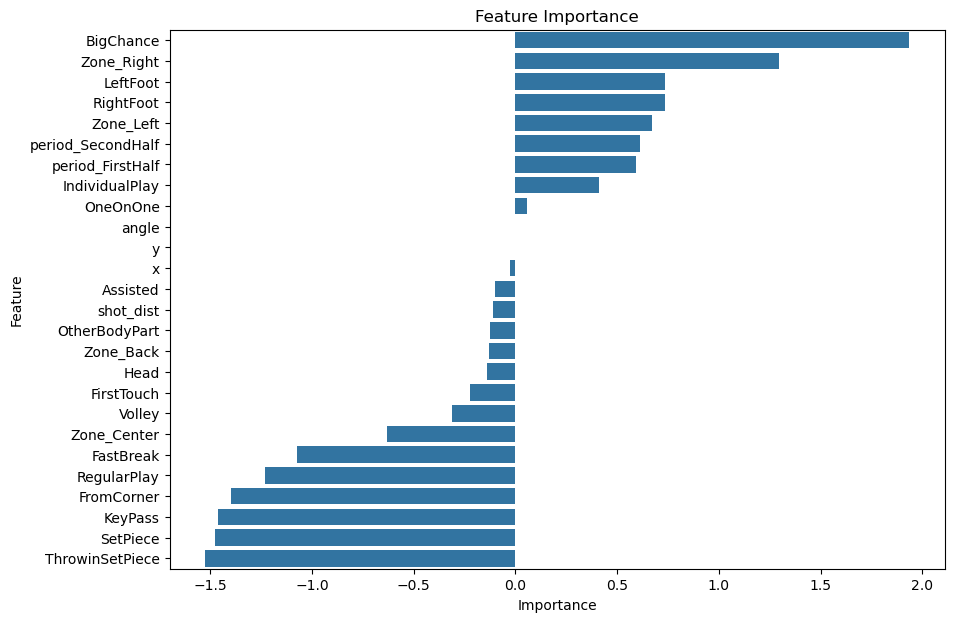

In [121]:
# plot the importance of the features
importance = model.coef_[0]
feature_names = X.columns
feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

,x,y,Assisted,IndividualPlay,RegularPlay,LeftFoot,RightFoot,FromCorner,FirstTouch,Head,...,angle,period_FirstHalf,period_SecondHalf,Zone_Back,Zone_Center,Zone_Left,Zone_Right,goal_predicted,goal_probability,Zone
3671,88.5,50.0,False,False,False,True,False,False,False,False,...,0.000000,False,True,False,True,False,False,True,0.767999,Center
6619,88.5,50.0,False,False,False,True,False,False,False,False,...,0.000000,False,True,False,True,False,False,True,0.767999,Center
1323,88.5,50.0,False,False,False,True,False,False,False,False,...,0.000000,False,True,False,True,False,False,True,0.767999,Center
381,88.5,50.0,False,False,False,True,False,False,False,False,...,0.000000,False,True,False,True,False,False,True,0.767999,Center
7387,88.5,50.0,False,False,False,False,True,False,False,False,...,0.000000,False,True,False,True,False,False,True,0.767994,Center
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7499,91.9,61.4,True,False,False,False,False,True,True,True,...,-54.605204,False,True,False,True,False,False,False,0.005907,Center
7893,50.1,49.9,False,False,True,True,False,False,False,False,...,0.114821,True,False,False,True,False,False,False,0.005407,Center
4450,44.6,68.2,False,True,False,True,False,False,False,False,...,-18.186379,False,True,True,False,False,False,False,0.005246,Back
1696,99.4,99.5,False,False,False,False,True,True,False,False,...,-89.305540,False,True,False,False,True,False,False,0.004715,Left


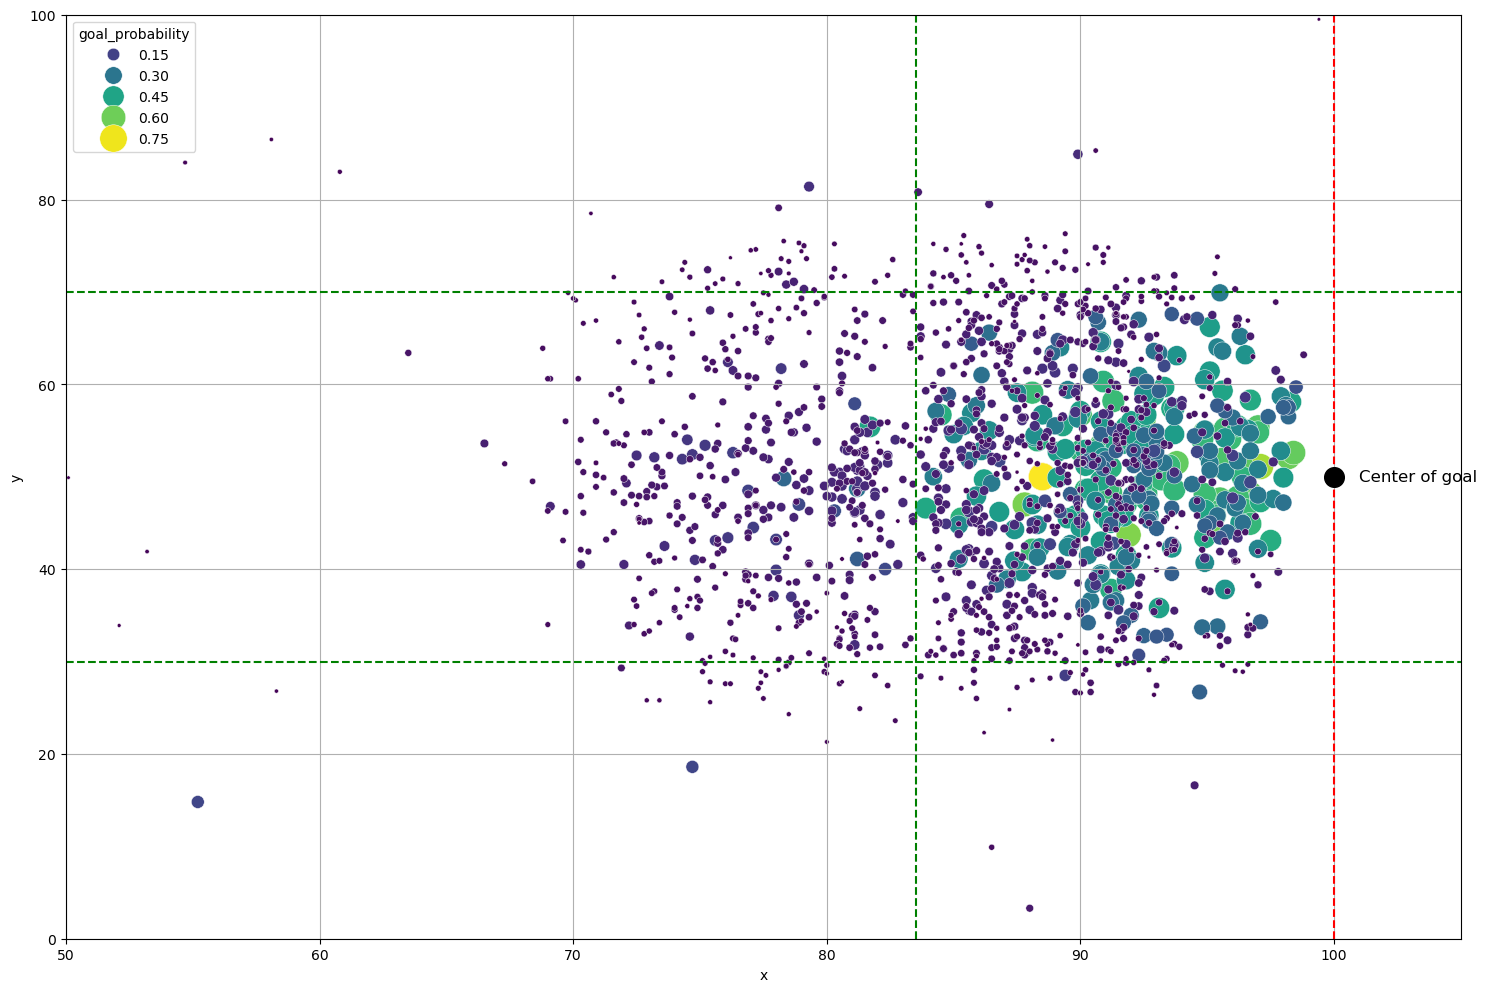

In [175]:
plt.figure(figsize=(18, 12))
sns.scatterplot(
    x='x', y='y', data=final_df, 
    hue='goal_probability', alpha=1.0, palette='viridis', 
    size='goal_probability', sizes=(5, 400)
)
plt.scatter(100, 50, color='black', s=200, zorder=5, label='Center of goal')  # s controls size
plt.text(100 + 1, 50, 'Center of goal', fontsize=12, verticalalignment='center')  # optional text label
plt.axvline(x=100, color='red', linestyle='--', label='Goalline')
plt.axhline(y=70, color='green', linestyle='--')
plt.axhline(y=30, color='green', linestyle='--')
plt.axvline(x=83.5, color='green', linestyle='--')
plt.xlim([50, 105])
plt.ylim(0, 100)
plt.grid()
# plt.legend()

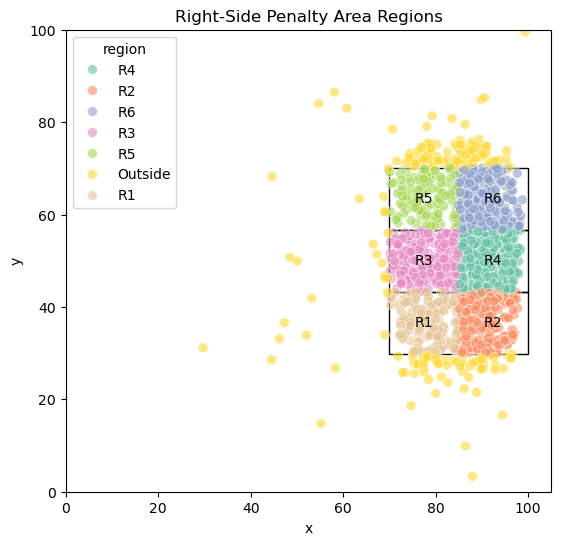

In [ ]:
def assign_region(x, y):
    # Define bounds
    x0 = 100 - 30  # penalty_box_x_start
    x1 = x0 + 30   # penalty_box_x_end
    y0 = (100 - 40.3) / 2
    y1 = y0 + 40.3

    if not (x0 <= x <= x1 and y0 <= y <= y1):
        return 'Outside'

    # Split into 3 vertical zones (top to bottom) and 2 horizontal (left to right)
    region_height = (y1 - y0) / 3
    region_width = 30 / 2

    row = int((y - y0) // region_height)  # 0, 1, 2
    col = int((x - x0) // region_width)   # 0, 1

    region_num = row * 2 + col + 1
    return f"R{region_num}"

final_df['region'] = final_df.apply(lambda row: assign_region(row['x'], row['y']), axis=1)




import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Set up the pitch
plt.figure(figsize=(10, 6))
plt.xlim([0, 105])
plt.ylim([0, 100])

# Define penalty box dimensions (standard: 16.5m deep, ~40.3m wide)
penalty_box_x_start = 100 - 30 
penalty_box_width = 30
penalty_box_y_start = (100 - 40.3) / 2  # center it
penalty_box_y_end = penalty_box_y_start + 40.3

# Split into 6 regions (3x2 grid: left, center, right × high, low)
region_height = (penalty_box_y_end - penalty_box_y_start) / 3
region_width = penalty_box_width / 2

# Create regions
for i in range(3):  # vertical split
    for j in range(2):  # horizontal split
        rect = patches.Rectangle(
            (penalty_box_x_start + j * region_width, penalty_box_y_start + i * region_height),
            region_width,
            region_height,
            linewidth=1,
            edgecolor='black',
            facecolor='none'
        )
        plt.gca().add_patch(rect)

        # Optional: label the region
        cx = penalty_box_x_start + j * region_width + region_width / 2
        cy = penalty_box_y_start + i * region_height + region_height / 2
        plt.text(cx, cy, f"R{i*2 + j + 1}", ha='center', va='center')

plt.title("Right-Side Penalty Area Regions")
plt.gca().set_aspect('equal', adjustable='box')

sns.scatterplot(
    x='x', y='y', data=final_df,
    hue='region', palette='Set2', alpha=0.6, s=50
)
plt.show()

/var/folders/jx/t1vcqq5n5r7629tr1v1zjkj80000gp/T/ipykernel_46438/20777794.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=region_means, x='region', y='goal_probability', palette=region_colors)


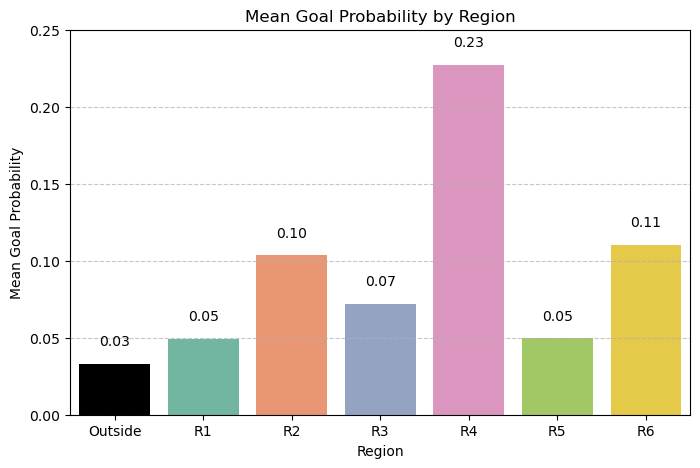

In [176]:
# Step 1: Compute region means
region_means = final_df.groupby('region')['goal_probability'].mean().sort_index().reset_index()

# Step 2: Create region_colors mapping
ordered_regions = region_means['region'].tolist()
n_non_outside = sum(r != 'Outside' for r in ordered_regions)
base_palette = sns.color_palette('Set2', n_colors=n_non_outside)

region_colors = {
    region: 'black' if region == 'Outside' else base_palette.pop(0)
    for region in ordered_regions
}

# Step 3: Bar plot
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=region_means, x='region', y='goal_probability', palette=region_colors)

# Add text labels on top of bars
for i, row in region_means.iterrows():
    plt.text(
        i, 
        row['goal_probability'] + 0.01,  # slightly above the bar
        f"{row['goal_probability']:.2f}", 
        ha='center', 
        va='bottom', 
        fontsize=10
    )

plt.title('Mean Goal Probability by Region')
plt.ylabel('Mean Goal Probability')
plt.xlabel('Region')
plt.ylim(0, region_means['goal_probability'].max() * 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()
